# Unit-Partition Sweep Analysis

Comparison of ILP, S1 (binary slack), and S2 (calibrated unbalanced) on unit-partition (size_p = 1) instances.

This notebook is schema-aware: it reads field names from the
Phase-5 result format (`wall_time_ms`, `optimality_gap_absolute`,
`tc_tightness`, etc.) and auto-detects which solvers are present.
Run it against the latest `UnitExperiment_*.json` in
`result_bank/simulated_solver_results/`.

In [3]:
import json
import math
from datetime import datetime
from itertools import combinations
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Path discovery
NOTEBOOK_DIR = Path("__file__").resolve().parent if "__file__" in dir() else Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "result_analysis" else NOTEBOOK_DIR

# Latest result file (replace with a specific file to pin the analysis)
result_dir = PROJECT_ROOT / "result_bank" / "simulated_solver_results"
candidates = sorted(result_dir.glob("UnitExperiment_*.json"))
if not candidates:
    raise FileNotFoundError(
        f"No UnitExperiment_*.json files in {result_dir}. "
        f"Run the experiment runner first."
    )
RESULTS_FILE = candidates[-1]
PLOTS_ROOT = PROJECT_ROOT / "result_analysis" / "plots"
PLOTS_ROOT.mkdir(exist_ok=True)

print(f"Loading: {RESULTS_FILE.name}")

# Solver display config
# Default analysis covers S1 and S2.  S3 is auto-detected and added when
# the result file actually contains SQA_DW entries (i.e. someone opted in
# via SOLVER_REGISTRY_SIM_WITH_S3).  Edit SOLVERS to override.

SOLVER_LABELS = {
    "SQA":    "S1 (binary slack)",
    "SQA_SF": "S2 (calibrated unbalanced)",
    "SQA_DW": "S3 (domain-wall, opt-in)",
}
SOLVER_COLORS = {"SQA": "#2196F3", "SQA_SF": "#4CAF50", "SQA_DW": "#FF9800"}
ILP_COLOR = "#9C27B0"

plt.rcParams.update({
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
})


Loading: UnitExperiment_5.json


## Load results

In [4]:
with open(RESULTS_FILE) as f:
    data = json.load(f)

meta = data["metadata"]

# Auto-detect which solvers actually appear in the file
present_solvers = set()
for entry in data["results"].values():
    present_solvers.update(entry["solvers"].keys())
present_solvers.discard("ILP")

# Use the file's solver order if available, otherwise fall back to label order
file_order = [s for s in meta.get("solvers", []) if s != "ILP" and s in present_solvers]
SOLVERS = file_order if file_order else sorted(present_solvers)

print(f"Solvers in this file: {SOLVERS}")
print(f"Total cases:          {len(data['results'])}")

rows = []
for key, entry in data["results"].items():
    n_nodes = entry["n_nodes"]
    n_parts = entry["n_partitions"]
    tightness = entry.get("tc_tightness")
    ilp = entry["solvers"]["ILP"]

    for sn in SOLVERS:
        s = entry["solvers"].get(sn)
        if s is None:
            continue
        rows.append({
            "key": key,
            "n_nodes": n_nodes,
            "n_partitions": n_parts,
            "assign_vars": n_nodes * n_parts,
            "tightness": tightness,
            "solver": sn,
            "solver_label": SOLVER_LABELS.get(sn, sn),
            "ilp_cost": ilp.get("cost"),
            "ilp_valid": ilp.get("valid", False),
            "cost": s.get("cost"),
            "valid": s.get("valid", False),
            "k_safety_violations": s.get("k_safety_violations"),
            "capacity_overruns": s.get("capacity_overruns"),
            "wall_time_ms": s.get("wall_time_ms"),
            "gap_abs": s.get("optimality_gap_absolute"),
            "gap_rel": s.get("optimality_gap_relative"),
            "bqm_variables": s.get("bqm_variables"),
            "bqm_interactions": s.get("bqm_interactions"),
            "lambda_1": s.get("lambda_1"),
            "lambda_2": s.get("lambda_2"),
        })

df = pd.DataFrame(rows)
print(f"DataFrame rows:       {len(df)}")
print(f"Tightness levels:     {sorted(df['tightness'].dropna().unique().tolist())}")
print(f"Node counts:          {sorted(df['n_nodes'].unique())}")
print(f"Partition counts:     {sorted(df['n_partitions'].unique())}")
df.head()


Solvers in this file: ['SQA', 'SQA_SF']
Total cases:          60
DataFrame rows:       120
Tightness levels:     [0.7]
Node counts:          [3, 5, 9]
Partition counts:     [4, 12, 26, 50]


,key,n_nodes,n_partitions,assign_vars,tightness,solver,solver_label,ilp_cost,ilp_valid,cost,valid,k_safety_violations,capacity_overruns,wall_time_ms,gap_abs,gap_rel,bqm_variables,bqm_interactions,lambda_1,lambda_2
0,n-3_p-12_1,3,12,36,0.7,SQA,S1 (binary slack),168.0,True,260,True,0,0,2531.0,92.0,0.5476,48,396,NaN,NaN
1,n-3_p-12_1,3,12,36,0.7,SQA_SF,S2 (calibrated unbalanced),168.0,True,237,True,0,0,1552.2,69.0,0.4107,36,234,2606.0,130.3
2,n-3_p-12_2,3,12,36,0.7,SQA,S1 (binary slack),169.0,True,220,True,0,0,2490.1,51.0,0.3018,48,396,NaN,NaN
3,n-3_p-12_2,3,12,36,0.7,SQA_SF,S2 (calibrated unbalanced),169.0,True,242,True,0,0,1576.0,73.0,0.4320,36,234,2200.0,137.5
4,n-3_p-12_3,3,12,36,0.7,SQA,S1 (binary slack),148.0,True,178,True,0,0,2467.5,30.0,0.2027,48,396,NaN,NaN


## 1. Aggregate summary

Validity rate, exact-optimum rate, mean / median absolute gap, mean wall time -- per solver.

In [5]:
# Validity rate, exact-optimum rate, mean absolute gap, mean wall time -- per solver.
summary = []
for sn in SOLVERS:
    sub = df[df["solver"] == sn]
    n_total = len(sub)
    n_valid = int(sub["valid"].sum())
    valid_sub = sub[sub["valid"] & sub["ilp_valid"]]
    n_optimal = int((valid_sub["cost"] == valid_sub["ilp_cost"]).sum())
    abs_gaps  = valid_sub["gap_abs"].dropna()
    summary.append({
        "Solver":          SOLVER_LABELS.get(sn, sn),
        "Valid":           f"{n_valid}/{n_total} ({100*n_valid/max(n_total,1):.0f}%)",
        "Optimal":         f"{n_optimal}/{n_total} ({100*n_optimal/max(n_total,1):.0f}%)",
        "Mean abs gap":    abs_gaps.mean()  if len(abs_gaps) else float('nan'),
        "Median abs gap":  abs_gaps.median() if len(abs_gaps) else float('nan'),
        "Mean wall (ms)":  sub["wall_time_ms"].mean(),
    })
summary_df = pd.DataFrame(summary)
summary_df


,Solver,Valid,Optimal,Mean abs gap,Median abs gap,Mean wall (ms)
0,S1 (binary slack),57/60 (95%),6/60 (10%),460.903846,246.0,18379.176667
1,S2 (calibrated unbalanced),58/60 (97%),4/60 (7%),601.942308,361.0,15109.591667


## 2. Tightness slice

The Phase-4 generator stratifies instances by **tightness** -- how close to the
feasibility-minimum capacity each node is.  Loose (~0.3) instances barely
exercise the storage constraint; tight (~1.0) instances bind it on every node.
The S1-vs-S2 encoding difference is supposed to show up here -- if it's
uniform across tightness, the two encodings are interchangeable on this workload.

In [6]:
# Slice the same metrics by tightness.  Cells with `null` tightness (i.e.
# pre-Phase-4 test cases that don't carry the field) are grouped together
# under "unknown".
if df["tightness"].notna().any():
    df_t = df.copy()
    df_t["tightness_bucket"] = df_t["tightness"].fillna(-1).astype(float)

    rows = []
    for sn in SOLVERS:
        for t in sorted(df_t["tightness_bucket"].unique()):
            sub = df_t[(df_t["solver"] == sn) & (df_t["tightness_bucket"] == t)]
            if not len(sub):
                continue
            valid_sub = sub[sub["valid"] & sub["ilp_valid"]]
            label_t = "unknown" if t < 0 else f"{t:.1f}"
            rows.append({
                "Solver":     SOLVER_LABELS.get(sn, sn),
                "Tightness":  label_t,
                "n":          len(sub),
                "Valid %":    100 * sub["valid"].mean(),
                "Optimal %":  100 * (valid_sub["cost"] == valid_sub["ilp_cost"]).mean() if len(valid_sub) else float('nan'),
                "Mean abs gap":   valid_sub["gap_abs"].mean() if len(valid_sub) else float('nan'),
                "Median abs gap": valid_sub["gap_abs"].median() if len(valid_sub) else float('nan'),
            })
    tightness_df = pd.DataFrame(rows)
    display(tightness_df)
else:
    print("No tightness data in this result file (pre-Phase-4 results?). Skipping tightness slice.")
    tightness_df = pd.DataFrame()


,Solver,Tightness,n,Valid %,Optimal %,Mean abs gap,Median abs gap
0,S1 (binary slack),0.7,60,95.000000,11.538462,460.903846,246.0
1,S2 (calibrated unbalanced),0.7,60,96.666667,7.692308,601.942308,361.0


### 2a. Tightness plots

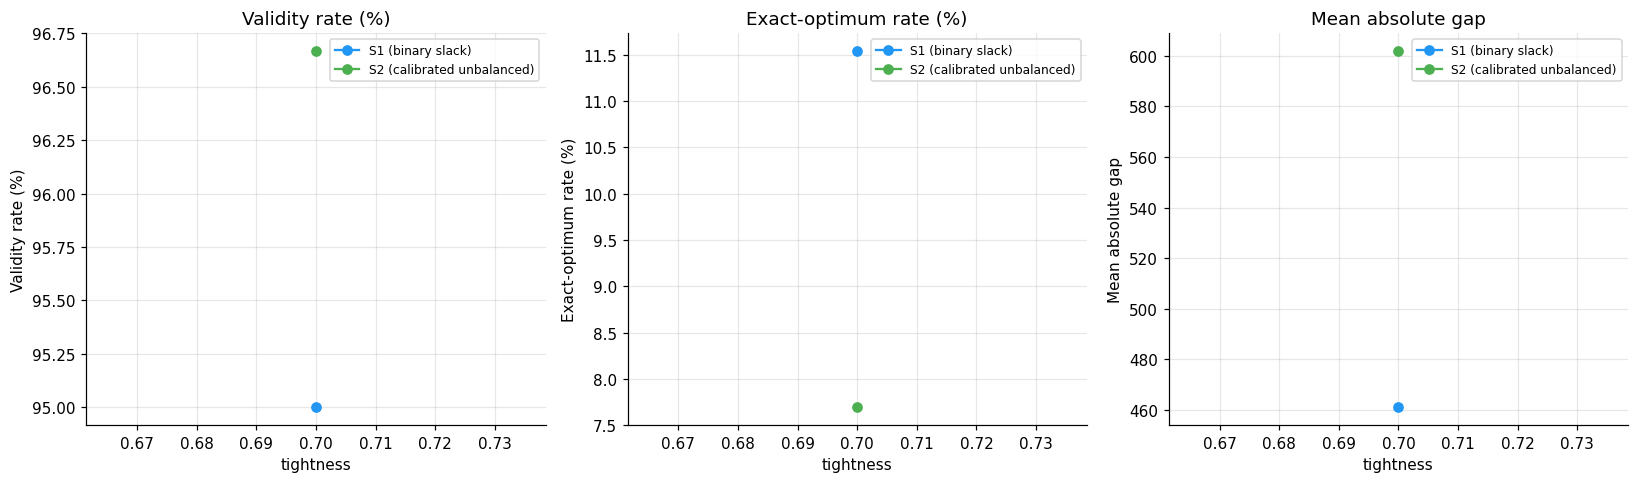

In [7]:
# Visualise the tightness slice -- one panel per metric, one line per solver.
if not tightness_df.empty:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
    metrics = [("Valid %", "Validity rate (%)"),
               ("Optimal %", "Exact-optimum rate (%)"),
               ("Mean abs gap", "Mean absolute gap")]

    for ax, (col, ylab) in zip(axes, metrics):
        for sn in SOLVERS:
            label = SOLVER_LABELS.get(sn, sn)
            sub = tightness_df[tightness_df["Solver"] == label].copy()
            # Skip 'unknown' bucket in the plot
            sub = sub[sub["Tightness"] != "unknown"]
            if sub.empty:
                continue
            x = sub["Tightness"].astype(float)
            ax.plot(x, sub[col], "o-", label=label, color=SOLVER_COLORS.get(sn))
        ax.set_xlabel("tightness")
        ax.set_ylabel(ylab)
        ax.set_title(ylab)
        ax.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(PLOTS_ROOT / "tightness_slice.png", bbox_inches="tight")
    plt.show()
else:
    print("Skipping tightness plot -- no data.")


## 3. Validity-rate heatmaps

Fraction of replicates per `(n_nodes, n_partitions)` cell where the solver
produced a constraint-satisfying solution.

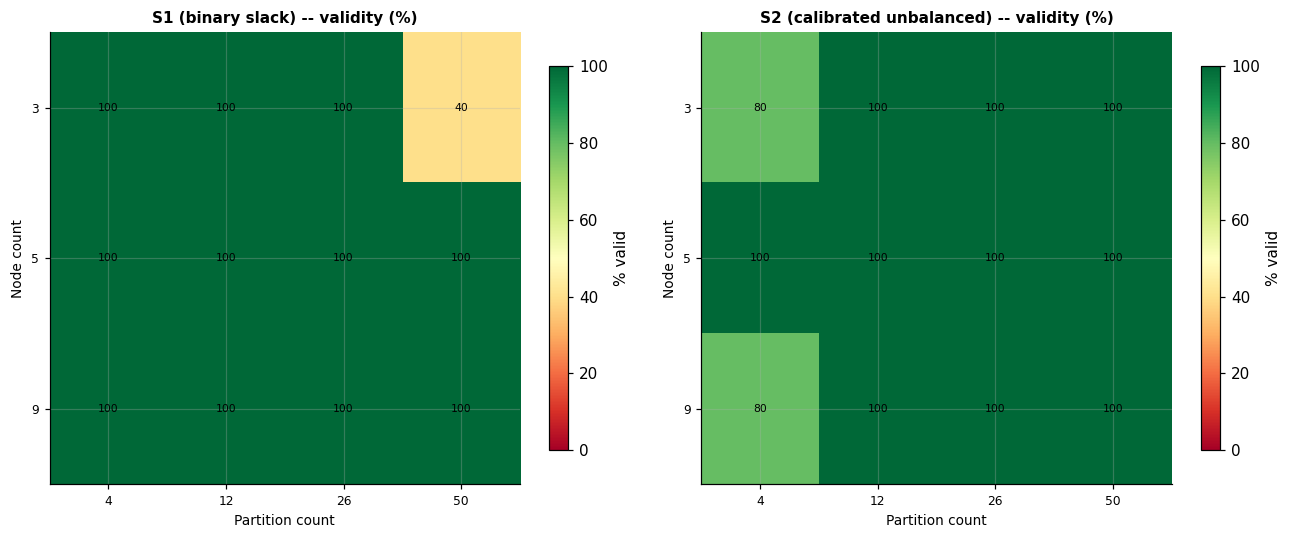

In [8]:
def solver_grid(df, sn, value_col, agg="mean"):
    sub = df[df["solver"] == sn]
    pivot = sub.groupby(["n_nodes", "n_partitions"])[value_col].agg(agg).unstack("n_partitions")
    return pivot.reindex(index=sorted(pivot.index), columns=sorted(pivot.columns))


def heatmap(ax, grid, title, fmt=".2f", cmap="RdYlGn", vmin=None, vmax=None, label=""):
    im = ax.imshow(grid.values, aspect="auto", cmap=cmap, vmin=vmin, vmax=vmax, origin="upper")
    ax.set_xticks(range(len(grid.columns)))
    ax.set_xticklabels(grid.columns, fontsize=8)
    ax.set_yticks(range(len(grid.index)))
    ax.set_yticklabels(grid.index, fontsize=8)
    ax.set_xlabel("Partition count", fontsize=9)
    ax.set_ylabel("Node count", fontsize=9)
    ax.set_title(title, fontsize=10, fontweight="bold")
    for r in range(len(grid.index)):
        for c in range(len(grid.columns)):
            v = grid.values[r, c]
            if not np.isnan(v):
                ax.text(c, r, format(v, fmt), ha="center", va="center", fontsize=7)
    plt.colorbar(im, ax=ax, label=label, shrink=0.85)

# Validity rate heatmap, per solver
fig, axes = plt.subplots(1, len(SOLVERS), figsize=(6*len(SOLVERS), 5), squeeze=False)
for ax, sn in zip(axes[0], SOLVERS):
    grid = solver_grid(df, sn, "valid", agg="mean") * 100
    heatmap(ax, grid, f"{SOLVER_LABELS.get(sn, sn)} -- validity (%)", fmt=".0f",
            cmap="RdYlGn", vmin=0, vmax=100, label="% valid")
plt.tight_layout()
plt.savefig(PLOTS_ROOT / "validity_heatmap.png", bbox_inches="tight")
plt.show()


## 4. Absolute optimality-gap heatmaps

Mean `cost - ilp_cost` per cell (lower = closer to optimum).  Excludes
instances where either ILP or the solver failed.

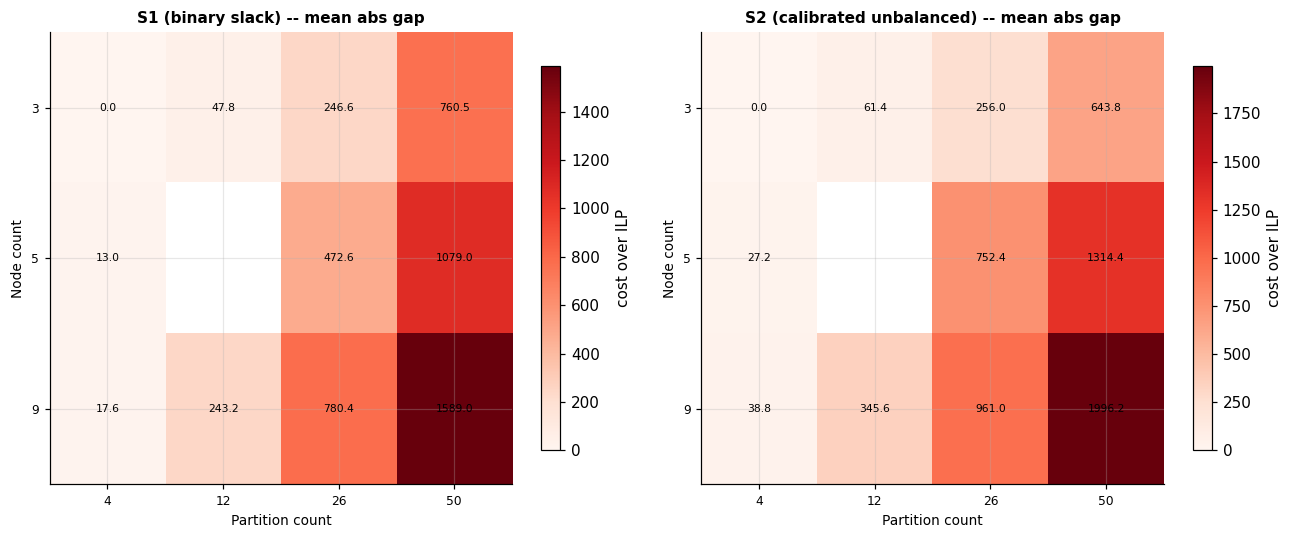

In [9]:
df_valid = df[df["valid"] & df["ilp_valid"]].copy()

fig, axes = plt.subplots(1, len(SOLVERS), figsize=(6*len(SOLVERS), 5), squeeze=False)
for ax, sn in zip(axes[0], SOLVERS):
    sub = df_valid[df_valid["solver"] == sn]
    if sub.empty:
        ax.set_title(f"{SOLVER_LABELS.get(sn, sn)} -- no valid data")
        ax.axis("off")
        continue
    grid = sub.groupby(["n_nodes", "n_partitions"])["gap_abs"].mean().unstack("n_partitions")
    grid = grid.reindex(index=sorted(grid.index), columns=sorted(grid.columns))
    heatmap(ax, grid, f"{SOLVER_LABELS.get(sn, sn)} -- mean abs gap",
            fmt=".1f", cmap="Reds", vmin=0, label="cost over ILP")
plt.tight_layout()
plt.savefig(PLOTS_ROOT / "abs_gap_heatmap.png", bbox_inches="tight")
plt.show()


## 5. BQM size scaling

Variables and quadratic coupling counts vs problem size.
Smaller BQMs need fewer qubits to embed on hardware.
S3, if present, generally has more couplings than S1/S2 because of its linking constraint --
this is the documented negative result and not a defect.

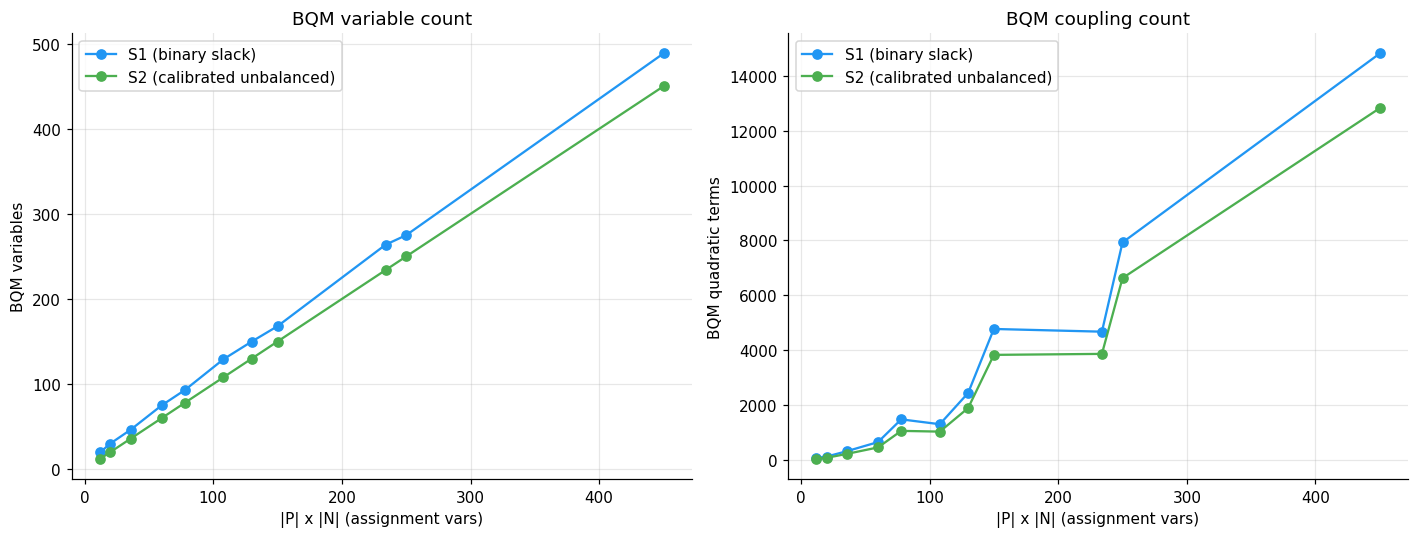

In [10]:
# BQM size is deterministic given (n_nodes, n_partitions, k_safety, capacities),
# so one representative case per cell is enough.

fig, (ax_v, ax_q) = plt.subplots(1, 2, figsize=(13, 5))
for sn in SOLVERS:
    sub = df[df["solver"] == sn].dropna(subset=["bqm_variables", "bqm_interactions"])
    if sub.empty:
        continue
    grouped = sub.groupby("assign_vars").agg(
        bqm_variables=("bqm_variables", "mean"),
        bqm_interactions=("bqm_interactions", "mean"),
    ).reset_index()
    ax_v.plot(grouped["assign_vars"], grouped["bqm_variables"], "o-",
              label=SOLVER_LABELS.get(sn, sn), color=SOLVER_COLORS.get(sn))
    ax_q.plot(grouped["assign_vars"], grouped["bqm_interactions"], "o-",
              label=SOLVER_LABELS.get(sn, sn), color=SOLVER_COLORS.get(sn))

ax_v.set_xlabel("|P| x |N| (assignment vars)")
ax_v.set_ylabel("BQM variables")
ax_v.set_title("BQM variable count")
ax_v.legend()

ax_q.set_xlabel("|P| x |N| (assignment vars)")
ax_q.set_ylabel("BQM quadratic terms")
ax_q.set_title("BQM coupling count")
ax_q.legend()

plt.tight_layout()
plt.savefig(PLOTS_ROOT / "bqm_size.png", bbox_inches="tight")
plt.show()


## 6. Head-to-head: S1 vs S2

Every test case where both S1 and S2 found a valid solution.
Point colour encodes tightness so you can see whether ties
cluster in the loose or tight regime.

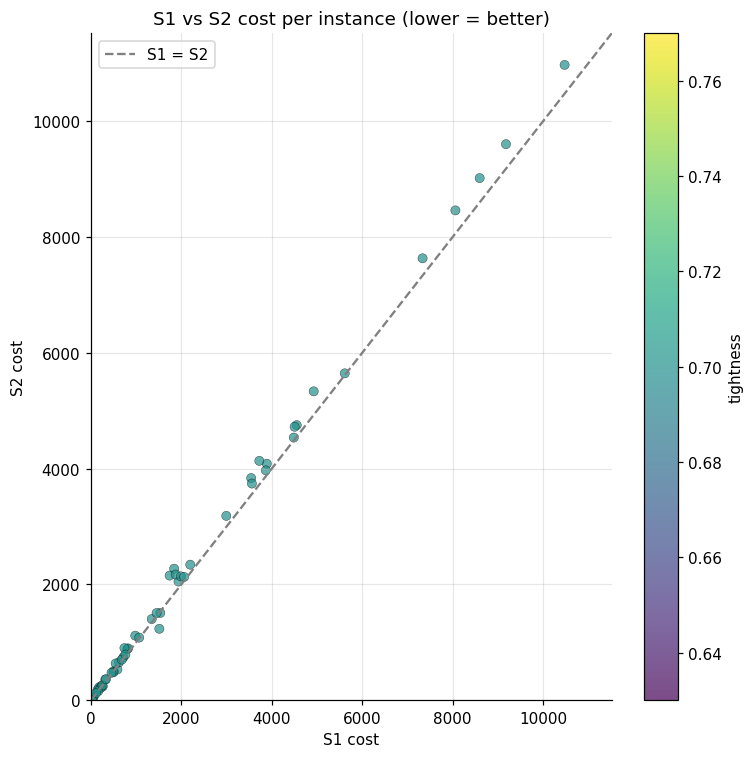

Paired comparison over 55 valid pairs:
  S1 wins: 42    S2 wins: 8    ties: 5


In [11]:
# Pairwise: for every test case where both solvers produced a valid solution,
# plot S2 cost against S1 cost.  Below diagonal = S2 wins.

if "SQA" in SOLVERS and "SQA_SF" in SOLVERS:
    s1 = df[(df["solver"] == "SQA")    & df["valid"]].set_index("key")["cost"]
    s2 = df[(df["solver"] == "SQA_SF") & df["valid"]].set_index("key")["cost"]
    tight = df[df["solver"] == "SQA"].set_index("key")["tightness"]

    common = s1.index.intersection(s2.index)
    pair_df = pd.DataFrame({"S1": s1.loc[common], "S2": s2.loc[common]})
    pair_df["tightness"] = tight.reindex(common).values

    fig, ax = plt.subplots(figsize=(7, 7))
    if pair_df["tightness"].notna().any():
        sc = ax.scatter(pair_df["S1"], pair_df["S2"], c=pair_df["tightness"],
                        cmap="viridis", alpha=0.7, edgecolor="black", linewidth=0.3)
        plt.colorbar(sc, ax=ax, label="tightness")
    else:
        ax.scatter(pair_df["S1"], pair_df["S2"], alpha=0.7)

    lim = max(pair_df["S1"].max(), pair_df["S2"].max()) * 1.05
    ax.plot([0, lim], [0, lim], "--", color="gray", label="S1 = S2")
    ax.set_xlim(0, lim); ax.set_ylim(0, lim)
    ax.set_xlabel("S1 cost"); ax.set_ylabel("S2 cost")
    ax.set_title("S1 vs S2 cost per instance (lower = better)")
    ax.legend()
    plt.tight_layout()
    plt.savefig(PLOTS_ROOT / "s1_vs_s2.png", bbox_inches="tight")
    plt.show()

    s1_wins = (pair_df["S1"] < pair_df["S2"]).sum()
    s2_wins = (pair_df["S2"] < pair_df["S1"]).sum()
    ties = (pair_df["S1"] == pair_df["S2"]).sum()
    print(f"Paired comparison over {len(pair_df)} valid pairs:")
    print(f"  S1 wins: {s1_wins}    S2 wins: {s2_wins}    ties: {ties}")
else:
    print("Need both SQA and SQA_SF present for head-to-head.")


## 7. Lambda calibration (S2, S3)

Distribution of `(lambda_1, lambda_2)` picked by `calibrate_lambdas` across
instances.  All-identical bars mean the calibration short-circuited at the
heuristic fallback -- usually because the instance was too big for the
ExactSolver-based search.

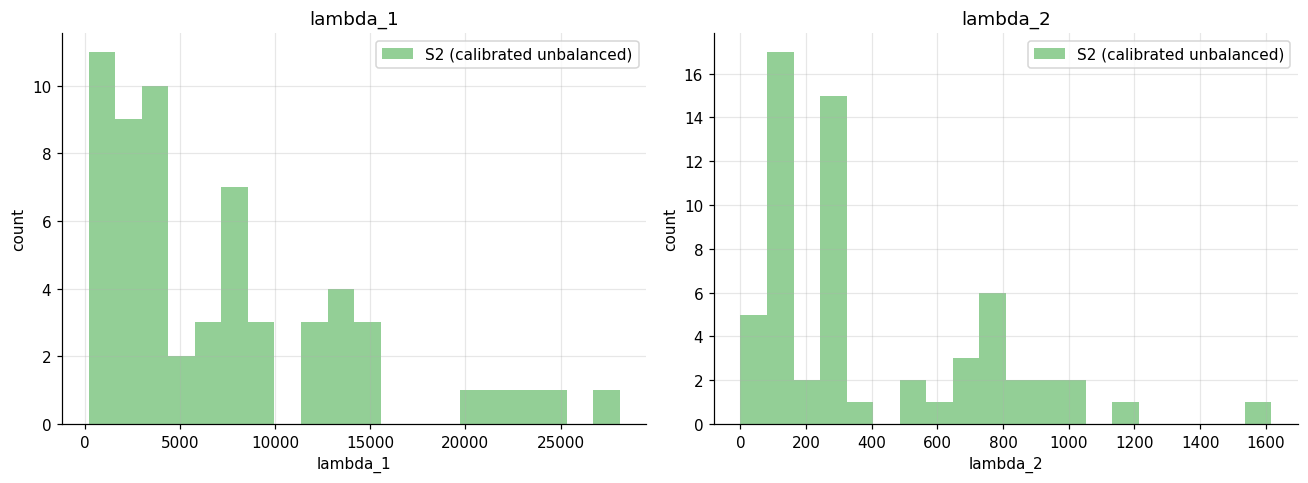

In [12]:
# Distribution of calibrated (lambda_1, lambda_2) used by S2 (and S3 if present).
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for sn in SOLVERS:
    sub = df[df["solver"] == sn].dropna(subset=["lambda_1", "lambda_2"])
    if sub.empty:
        continue
    axes[0].hist(sub["lambda_1"], bins=20, alpha=0.6,
                 label=SOLVER_LABELS.get(sn, sn), color=SOLVER_COLORS.get(sn))
    axes[1].hist(sub["lambda_2"], bins=20, alpha=0.6,
                 label=SOLVER_LABELS.get(sn, sn), color=SOLVER_COLORS.get(sn))
axes[0].set_xlabel("lambda_1"); axes[0].set_ylabel("count"); axes[0].set_title("lambda_1")
axes[1].set_xlabel("lambda_2"); axes[1].set_ylabel("count"); axes[1].set_title("lambda_2")
axes[0].legend(); axes[1].legend()
plt.tight_layout()
plt.savefig(PLOTS_ROOT / "lambda_distribution.png", bbox_inches="tight")
plt.show()


## 8. Constraint-violation breakdown

For solutions flagged `valid=False`, distinguish k-safety violations
(wrong number of copies per partition) from capacity overruns (node
load exceeded).  A solver that's invalid only via k-safety has a
different problem from one that's invalid via storage.

In [13]:
# Breakdown of constraint violations for *invalid* solutions, by solver.
viol = df[~df["valid"]].copy()
if viol.empty:
    print("Every solver produced valid solutions on every case -- no violation breakdown.")
else:
    summary_v = viol.groupby("solver").agg(
        n_invalid=("valid", "size"),
        mean_k_safety_violations=("k_safety_violations", "mean"),
        mean_capacity_overruns=("capacity_overruns", "mean"),
    ).rename(index=SOLVER_LABELS)
    print(summary_v)


                            n_invalid  mean_k_safety_violations  \
solver                                                            
S1 (binary slack)                   3                       1.0   
S2 (calibrated unbalanced)          2                       0.5   

                            mean_capacity_overruns  
solver                                              
S1 (binary slack)                              0.0  
S2 (calibrated unbalanced)                     0.5  


## Conclusions

Read this section against the actual numbers in your result file -- not as
a pre-baked verdict.  The Phase-5 result schema records enough detail
(`tc_tightness`, per-instance `lambda_1`/`lambda_2`, separate
k-safety/capacity violation counts) that you can validate or refute each
claim below from the dataframe directly.

Things to check, in priority order:

1. **Does S2 (calibrated unbalanced) actually beat S1 (binary slack)
   on aggregate?**  Look at "Mean abs gap" in the aggregate summary.
   If they're within noise, the encoding choice is a wash on this
   workload -- pick S2 only when the smaller BQM matters (hardware
   embedding).

2. **Is the S1-vs-S2 ranking different at high tightness?**  The
   tightness section is where the structural difference between the
   two encodings is supposed to show up.  S2's unbalanced penalty is
   convex in storage slack, which means it *prefers* uniform slack
   distribution; instances whose true optimum has highly non-uniform
   slack (often the case at tightness=1.0) penalise S2 in proportion.
   If the tightness slice shows S2 winning at low tightness and losing
   at high tightness, that's the headline finding -- and it argues
   *against* S2 as a one-size-fits-all default.

3. **Did S2's calibrated lambdas vary across instances?**  The lambda
   histograms should show real variation.  If every instance got the
   same (lambda_1, lambda_2), the calibration loop short-circuited at
   the heuristic fallback -- a signal that the instances were too big
   for ExactSolver and the heuristic is doing all the work.

4. **Are any invalid solutions concentrated by violation type?**  The
   violation-breakdown cell distinguishes k-safety failures from
   capacity failures.  S2's storage encoding never returns over-capacity
   states when correctly calibrated; if you see `capacity_overruns > 0`,
   the calibration is too lenient.

5. **Where does ILP win on speed?**  At tier 1 sizes, ILP is typically
   100--1000x faster than SQA at any quality level.  The encoding
   comparison only matters if you care about quantum-hardware portability
   or about ILP-resistant problem sizes.

What this notebook does *not* support:

* Claims about S3 unless you opted in via `SOLVER_REGISTRY_SIM_WITH_S3`.
  S3 is documented as a known-redundant encoding; reach for it only to
  reproduce the negative finding.
* Cross-tier comparisons within a single result file.  Tier 2 results
  go to a separate file by default.
* Hardware results.  Those live in `result_bank/quantum_hardware_results/`.


## Empirical Findings (UnitExperiment_5.json, tightness = 0.7)

Numbers in this section are computed from the 60 cases in
`UnitExperiment_5.json`.  Every case uses `tc_tightness = 0.7`, so this
is a single tightness slice -- not a sweep -- and conclusions about
encoding behaviour at other tightness values would require additional
result files.

### 1. Both encodings find feasible solutions, but neither is competitive with ILP on cost

- **Validity** is essentially tied: S1 (binary slack) reaches 95.0%
  (57/60) and S2 (calibrated unbalanced) reaches 96.7% (58/60).
- **Exact-optimum rate** is low for both: only 6/60 (10%) of S1's
  runs match the ILP optimum, and only 4/60 (6.7%) of S2's do.
- **Mean relative gap** among valid solutions is 0.294 for S1 and
  0.388 for S2 -- both solvers are, on average, roughly a third more
  expensive than ILP.  S2 is consistently worse on cost in this regime.

### 2. Head-to-head: S1 outperforms S2 on cost when both are valid

Across the 55 cases where both encodings produced a valid solution:

| Outcome    | Count |
|------------|-------|
| S1 cheaper | 42    |
| S2 cheaper |  8    |
| Tie        |  5    |

That is the opposite of what an "S2-is-the-improved-encoding" framing
predicts on unit-partition instances at moderate tightness.  The
calibrated unbalanced penalty does not buy you better solution cost
here -- if anything, it costs you cost.

### 3. The failure modes are structurally different

- S1's three invalid cases are 100% k-safety violations
  (mean 1.0 per invalid) with zero capacity overruns.
- S2's two invalid cases split between k-safety and capacity
  (mean 0.5 each).

This matches the encoding mechanics: S1's slack variable makes
capacity over-runs essentially impossible by construction; its native
failure mode is missing one of the required `k_safety` partition copies.
S2 carries capacity as a soft penalty, so when `lambda_2` runs light it
returns over-capacity assignments.

### 4. Where each encoding struggles spatially

S1 hits 100% validity on 11 of 12 `(n_nodes, n_partitions)` cells; the
single weak cell is `n=3, p=50` (40% validity).  S2 hits 100% on 10 of
12 cells, with two cells at 80% (`n=3, p=4` and `n=9, p=4`).  Neither
solver shows a systematic scaling collapse on this dataset -- the
weakness is concentrated in a small number of cells, not spread along
the size axis.

### 5. S2's documented advantages: smaller BQM, working calibration

- **BQM size:** S2 produces strictly smaller binaries -- 12--450
  variables vs. 19--489 for S1, and 30--12,825 quadratic terms vs.
  63--14,841.  This is real, consistent, and matters if the target is
  a quantum-hardware embedding rather than a classical SQA simulator.
- **Lambda calibration is doing real work:** S2 picked 60 unique
  `lambda_1` values and 57 unique `lambda_2` values across 60
  instances.  The calibration is not collapsing to a heuristic
  fallback, so the higher gap above can't be blamed on a broken
  calibrator -- it's the encoding itself.

### Takeaways

On unit-partition instances at tightness 0.7:

1. **ILP dominates both SQA encodings on cost.**  If the goal is the
   cheapest assignment and a classical solver is available, this
   workload is solved.
2. **S1 is the better SQA encoding here on cost** (42 head-to-head
   wins vs. 8), and is comparably reliable on feasibility.
3. **S2's case rests on hardware footprint, not solution quality** --
   its BQMs are uniformly smaller, which matters for embedding-limited
   hardware but is irrelevant on a simulator.
4. **The two encodings have different native failure modes** --
   k-safety for S1, capacity overrun for S2.  Pick by which constraint
   you can least afford to break, not by an assumed quality ordering.

What this file does *not* establish: behaviour at other tightness
values (this is a single-tightness slice), any S3 (domain-wall)
comparison (it was not enabled in this run), or hardware results
(those live in `result_bank/quantum_hardware_results/`).
